# PEC edge classification: legacy vs. conformal geometry

This notebook visualizes how the legacy and conformal STL geometry pipelines
classify **primary FIT edges** in a simple rectangular PEC beam pipe.

The goal is not to compare wakefields yet, but to directly inspect the
**discretized PEC/vacuum topology** used by the solver.

In particular, this notebook highlights the issue that motivated the move from
cell masks to point masks:

- In the **legacy** pipeline, material assignment is inherited cell-wise and
  attached to the lower edges of each cell.
- Near a PEC/vacuum interface, this can create a staircase-like or
  ``U``-shaped PEC representation on the primary grid.
- In the **conformal** pipeline, the STL classification is first performed on
  grid points, and the material assignment is then derived from those point
  masks.

The geometry is intentionally chosen to be simple and the mesh intentionally
chosen to be rather coarse, so that the difference becomes visible.

The final figure shows three panels:

1. the exact rectangular STL geometry,
2. the **legacy** edge classification,
3. the **conformal** edge classification.

Dark gray edges are treated as **PEC**, light gray edges as **vacuum**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from wakis import GridFIT3D, SolverFIT3D

## Geometry and mesh

We model the cross-section of a rectangular beam pipe by using **two STL solids**:

- an outer **PEC block**,
- an inner **vacuum channel**.

This keeps the full PEC/vacuum interface STL-defined, while remaining easy to
construct and visualize.

The computational background is also set to vacuum.

In [2]:
# ------------------------------------------------------------------
# Outer computational domain / outer PEC block
# ------------------------------------------------------------------
xmin, xmax = 0.0, 0.120

ymin, ymax = 0.0, 0.080
zmin, zmax = 0.0, 0.060

# ------------------------------------------------------------------
# Inner vacuum channel (intentionally not aligned with the grid)
# ------------------------------------------------------------------
pipe_xmin, pipe_xmax = 0.034, 0.086
pipe_ymin, pipe_ymax = 0.023, 0.057

# ------------------------------------------------------------------
# Coarse grid to make the classification differences visible
# ------------------------------------------------------------------
Nx, Ny, Nz = 12, 8, 4

dx = (xmax - xmin) / Nx
dy = (ymax - ymin) / Ny
dz = (zmax - zmin) / Nz

print(f"Grid: {Nx} x {Ny} x {Nz}")
print(f"dx = {dx*1e3:.2f} mm, dy = {dy*1e3:.2f} mm, dz = {dz*1e3:.2f} mm")
print()
print("Inner vacuum channel bounds:")
print(f"x in [{pipe_xmin*1e3:.1f}, {pipe_xmax*1e3:.1f}] mm")
print(f"y in [{pipe_ymin*1e3:.1f}, {pipe_ymax*1e3:.1f}] mm")

Grid: 12 x 8 x 4
dx = 10.00 mm, dy = 10.00 mm, dz = 15.00 mm

Inner vacuum channel bounds:
x in [34.0, 86.0] mm
y in [23.0, 57.0] mm


In [3]:
# ------------------------------------------------------------------
# Generate STL files locally inside notebooks/_011_generated
# ------------------------------------------------------------------
generated_dir = Path("_011_generated")
generated_dir.mkdir(parents=True, exist_ok=True)

pec_stl = generated_dir / "rectangular_outer_pec_block.stl"
vacuum_stl = generated_dir / "rectangular_inner_vacuum_channel.stl"

outer_block = pv.Box(bounds=(xmin, xmax, ymin, ymax, zmin, zmax)).triangulate()
inner_channel = pv.Box(
    bounds=(pipe_xmin, pipe_xmax, pipe_ymin, pipe_ymax, zmin, zmax)
).triangulate()

outer_block.save(str(pec_stl))
inner_channel.save(str(vacuum_stl))

stl_solids = {
    "pec_block": str(pec_stl),
    "vacuum_channel": str(vacuum_stl),
}

# Order matters: the vacuum channel is applied after the PEC block so that the
# inner channel overwrites the PEC region inside the pipe.
stl_materials = {
    "pec_block": "pec",
    "vacuum_channel": "vacuum",
}

print("Generated STL files:")
print(f"- {pec_stl.name}")
print(f"- {vacuum_stl.name}")

Generated STL files:
- rectangular_outer_pec_block.stl
- rectangular_inner_vacuum_channel.stl


## Build legacy and conformal solvers

Both runs use the same STL geometry and the same STL classification method:
`voxelize_rectilinear`.

The only difference is the `geometry_mode`:

- `legacy`
- `conformal`

In [4]:
def build_solver(geometry_mode):
    grid = GridFIT3D(
        xmin,
        xmax,
        ymin,
        ymax,
        zmin,
        zmax,
        Nx,
        Ny,
        Nz,
        stl_solids=stl_solids,
        stl_materials=stl_materials,
        stl_method="voxelize_rectilinear",
        geometry_mode=geometry_mode,
        subpixel_smoothing=False,
        stl_scale=1.0,
        stl_rotate=[0.0, 0.0, 0.0],
        stl_translate=[0.0, 0.0, 0.0],
        verbose=1,
    )

    solver = SolverFIT3D(
        grid=grid,
        bc_low=["pec", "pec", "pec"],
        bc_high=["pec", "pec", "pec"],
        use_stl=True,
        bg="vacuum",
        verbose=1,
    )
    return grid, solver


grid_legacy, solver_legacy = build_solver("legacy")
grid_conformal, solver_conformal = build_solver("conformal")

Generating grid with 384 mesh cells...
Importing STL solids...
 * Marking cells inside STL solid 'pec_block'...
    * STL solid pec_block: 384 cells marked inside the solid.
 * Marking cells inside STL solid 'vacuum_channel'...
    * STL solid vacuum_channel: 60 cells marked inside the solid.
Total grid initialization time: 0.06924772262573242 s
Initializing Electromagnetic solver...
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
Calculating maximal stable timestep...
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 0.006911039352416992 s
Generating grid with 384 mesh cells...
Importing STL solids...
 * Marking grid points inside STL solid 'pec_block'...
    * STL solid pec_block: 468 primal points, 288 cell centers, and 351 dual points marked inside the solid.
 * Marking grid points inside STL solid 'vacuum_channel'...
    * STL solid vacuum_channel: 60 primal points, 24 cell centers, and 24 dual poin

In [6]:
def get_pec_edge_masks_xy(solver, k_slice):
    ieps_x = np.real(solver.ieps.to_matrix("x"))
    ieps_y = np.real(solver.ieps.to_matrix("y"))

    pec_x = np.isclose(
        ieps_x[:, :, k_slice],
        0.0,
    )

    pec_y = np.isclose(
        ieps_y[:, :, k_slice],
        0.0,
    )

    return pec_x, pec_y

# We inspect the middle xy slice.
k_slice = Nz // 2
z_value = solver_legacy.grid.z[k_slice]

legacy_pec_x, legacy_pec_y = get_pec_edge_masks_xy(
    solver_legacy,
    k_slice,
)

conformal_pec_x, conformal_pec_y = get_pec_edge_masks_xy(
    solver_conformal,
    k_slice,
)

print(
    f"Using xy slice at k = {k_slice}, "
    f"z = {z_value * 1e3:.2f} mm"
)

print()
print("Number of PEC edges in the selected slice:")

print(
    "legacy    :",
    np.sum(legacy_pec_x)
    + np.sum(legacy_pec_y),
)

print(
    "conformal :",
    np.sum(conformal_pec_x)
    + np.sum(conformal_pec_y),
)

Using xy slice at k = 2, z = 30.00 mm

Number of PEC edges in the selected slice:
legacy    : 162
conformal : 182


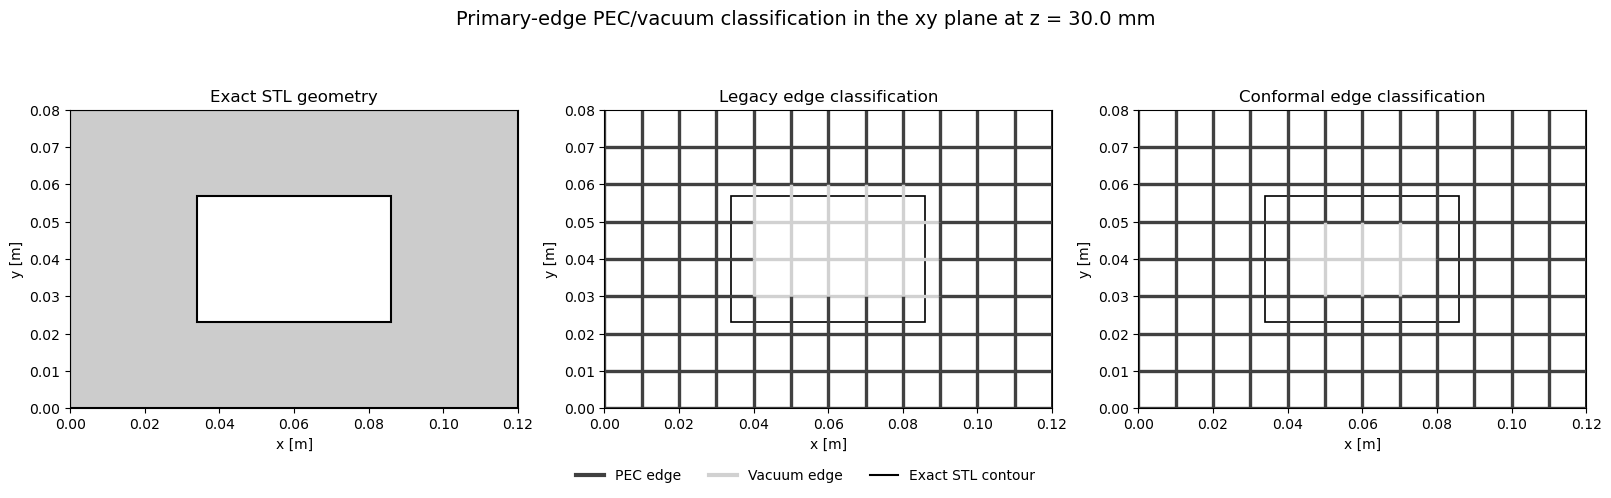

In [7]:
def draw_geometry_reference(ax):
    # Exact PEC shell / vacuum channel cross-section
    ax.add_patch(
        Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            facecolor="0.80",
            edgecolor="k",
            linewidth=1.5,
        )
    )
    ax.add_patch(
        Rectangle(
            (pipe_xmin, pipe_ymin),
            pipe_xmax - pipe_xmin,
            pipe_ymax - pipe_ymin,
            facecolor="white",
            edgecolor="k",
            linewidth=1.5,
        )
    )

    # Overlay the primal grid for orientation
    for x in grid_legacy.x:
        ax.plot([x, x], [ymin, ymax], color="0.90", lw=0.8, zorder=0)
    for y in grid_legacy.y:
        ax.plot([xmin, xmax], [y, y], color="0.90", lw=0.8, zorder=0)

    ax.set_title("Exact STL geometry")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


def draw_edge_classification(ax, solver, title):
    x = solver.grid.x
    y = solver.grid.y

    ex_pec, ey_pec = get_pec_edge_masks_xy(
        solver,
        k_slice,
    )

    # Draw exact geometry contour for reference
    ax.add_patch(
        Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor="k",
            linewidth=1.2,
        )
    )
    ax.add_patch(
        Rectangle(
            (pipe_xmin, pipe_ymin),
            pipe_xmax - pipe_xmin,
            pipe_ymax - pipe_ymin,
            fill=False,
            edgecolor="k",
            linewidth=1.2,
        )
    )

    # Horizontal primary edges: E_x
    for i in range(solver.Nx):
        for j in range(solver.Ny):
            color = "0.25" if ex_pec[i, j] else "0.82"
            ax.plot(
                [x[i], x[i + 1]],
                [y[j], y[j]],
                color=color,
                lw=2.4,
                solid_capstyle="butt",
            )

    # Vertical primary edges: E_y
    for i in range(solver.Nx):
        for j in range(solver.Ny):
            color = "0.25" if ey_pec[i, j] else "0.82"
            ax.plot(
                [x[i], x[i]],
                [y[j], y[j + 1]],
                color=color,
                lw=2.4,
                solid_capstyle="butt",
            )

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

draw_geometry_reference(axes[0])
draw_edge_classification(axes[1], solver_legacy, "Legacy edge classification")
draw_edge_classification(axes[2], solver_conformal, "Conformal edge classification")

legend_handles = [
    Line2D([0], [0], color="0.25", lw=3, label="PEC edge"),
    Line2D([0], [0], color="0.82", lw=3, label="Vacuum edge"),
    Line2D([0], [0], color="k", lw=1.5, label="Exact STL contour"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
)

fig.suptitle(
    f"Primary-edge PEC/vacuum classification in the xy plane at z = {z_value*1e3:.1f} mm",
    fontsize=14,
)

plt.show()

## Interpretation

This example illustrates the motivation for introducing a point-based geometry
representation.

In the legacy approach, cell-based material information is inherited by the
lower-oriented primary edges of each cell. Near a PEC-vacuum interface, this
can produce artificial PEC edge extensions perpendicular to the actual material
boundary.

The point-based approach avoids this particular ambiguity by deriving the edge
classification from primal point information. The resulting material topology
is therefore more consistent with the underlying STL geometry.

At the current stage, however, the exact STL-grid intersection positions are
not yet used. The discrete material boundary can therefore still be shifted
relative to the exact STL surface. This point-based representation is intended
as the geometric foundation for a subsequent intersection-aware material
discretization.